# 梯度提升就是每一步针对残差的负值进行拟合，按一定权重加到上一个预测函数中



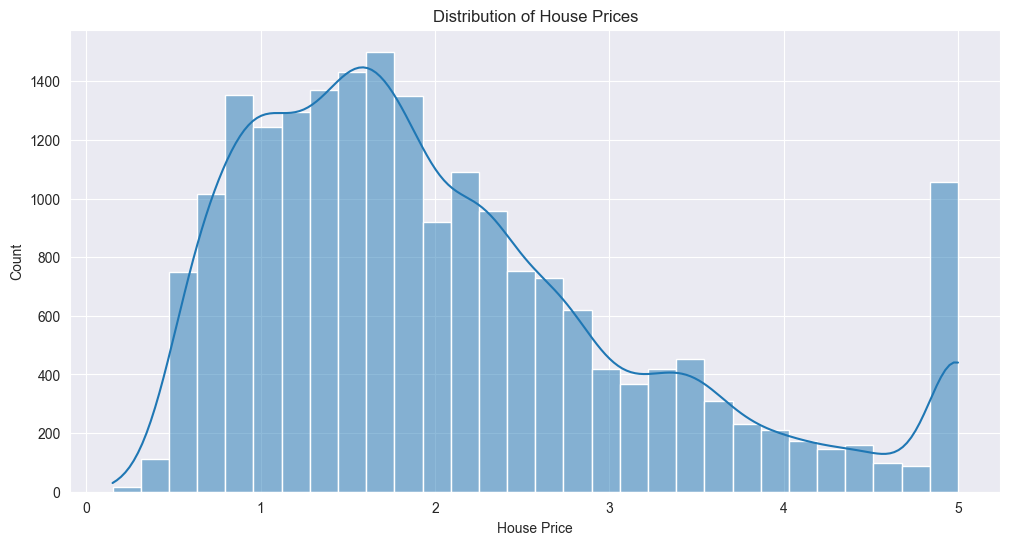

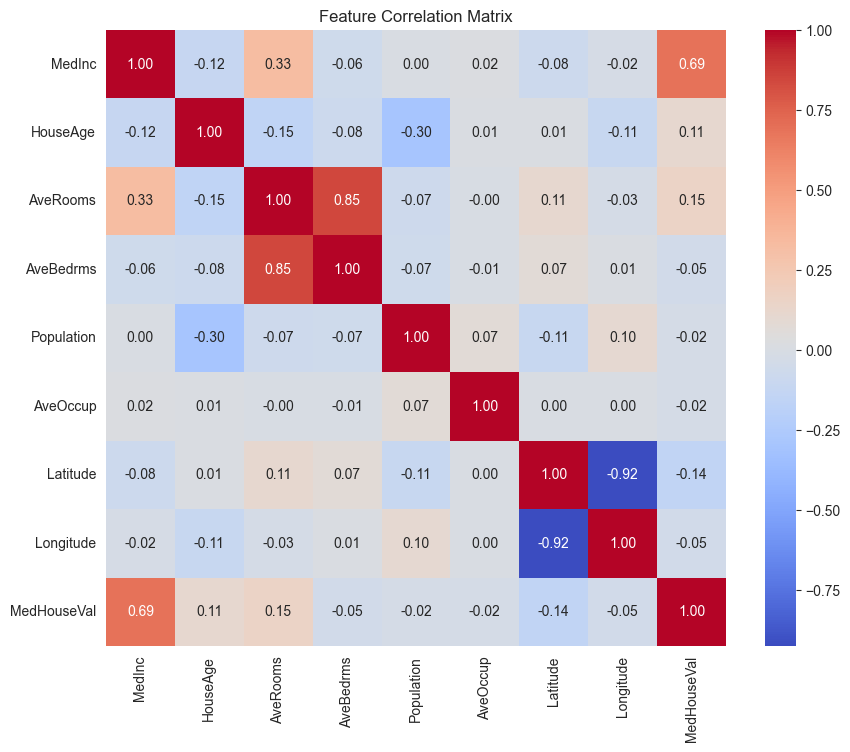

Mean Squared Error: 0.2378
R2 Score: 0.8185


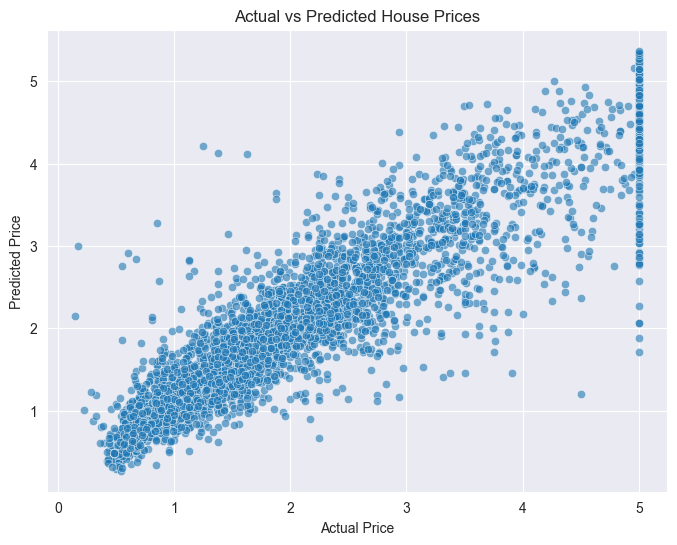

Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Optimized MSE: 0.2139
Optimized R2 Score: 0.8368


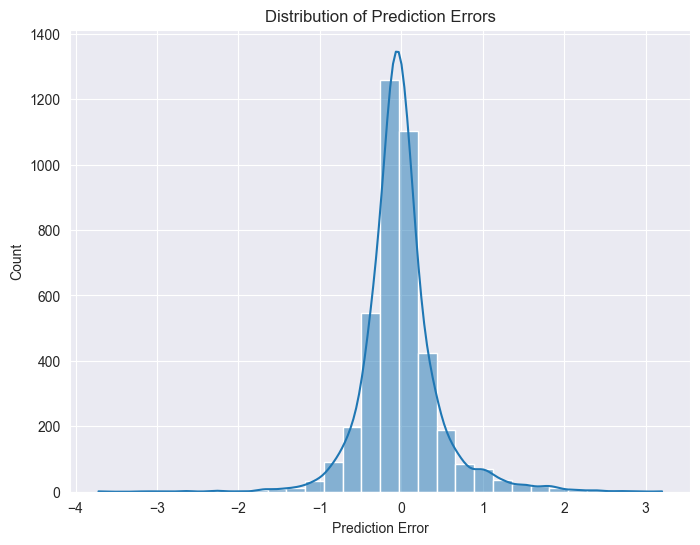

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. 加载数据
#data = fetch_california_housing()
#df = pd.DataFrame(data.data, columns=data.feature_names)
df = pd.read_csv("./fetched_california_housing.csv")

# 2. 数据可视化
plt.figure(figsize=(12, 6))
sns.histplot(df['MedHouseVal'], bins=30, kde=True)
plt.xlabel("House Price")
plt.ylabel("Count")
plt.title("Distribution of House Prices")
plt.show()

# 3. 变量之间的相关性
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

# 4. 数据拆分
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 训练梯度提升回归模型
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# 6. 预测与评估
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

# 7. 真实值 vs 预测值
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# 8. 超参数优化
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}
grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

# 9. 重新训练最优模型
best_model = grid_search.best_estimator_
y_best_pred = best_model.predict(X_test)

# 10. 评估优化后模型
best_mse = mean_squared_error(y_test, y_best_pred)
best_r2 = r2_score(y_test, y_best_pred)
print(f"Optimized MSE: {best_mse:.4f}")
print(f"Optimized R2 Score: {best_r2:.4f}")

# 11. 误差分布
plt.figure(figsize=(8, 6))
sns.histplot(y_test - y_best_pred, bins=30, kde=True)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.show()